In [4]:
import math

import numpy as np
from numpy.polynomial.hermite import hermgauss
from tqdm import tqdm
from matplotlib import pyplot as plt
from solver import LoanParams, LoanTraderSolver
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import joblib
from plots import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
params = LoanParams(
    # kappa=0.2,
    # delta=0.8, 
    theta_mode='fixed',
    theta_fixed=0.1,
)


solver = LoanTraderSolver(params)

In [6]:
value, opt_g, opt_p = solver.solve()

Backward induction: 100%|██████████| 120/120 [01:26<00:00,  1.39it/s]


In [7]:
file_name = 'solver_theta_0_1.pkl'

solver.save(file_name)
# solver = LoanTraderSolver.load(file_name)

In [8]:
sim = solver.simulate(
    r0=0.05,
    c0=0.05,
    k0=0.20,
    nsim=1000,
)

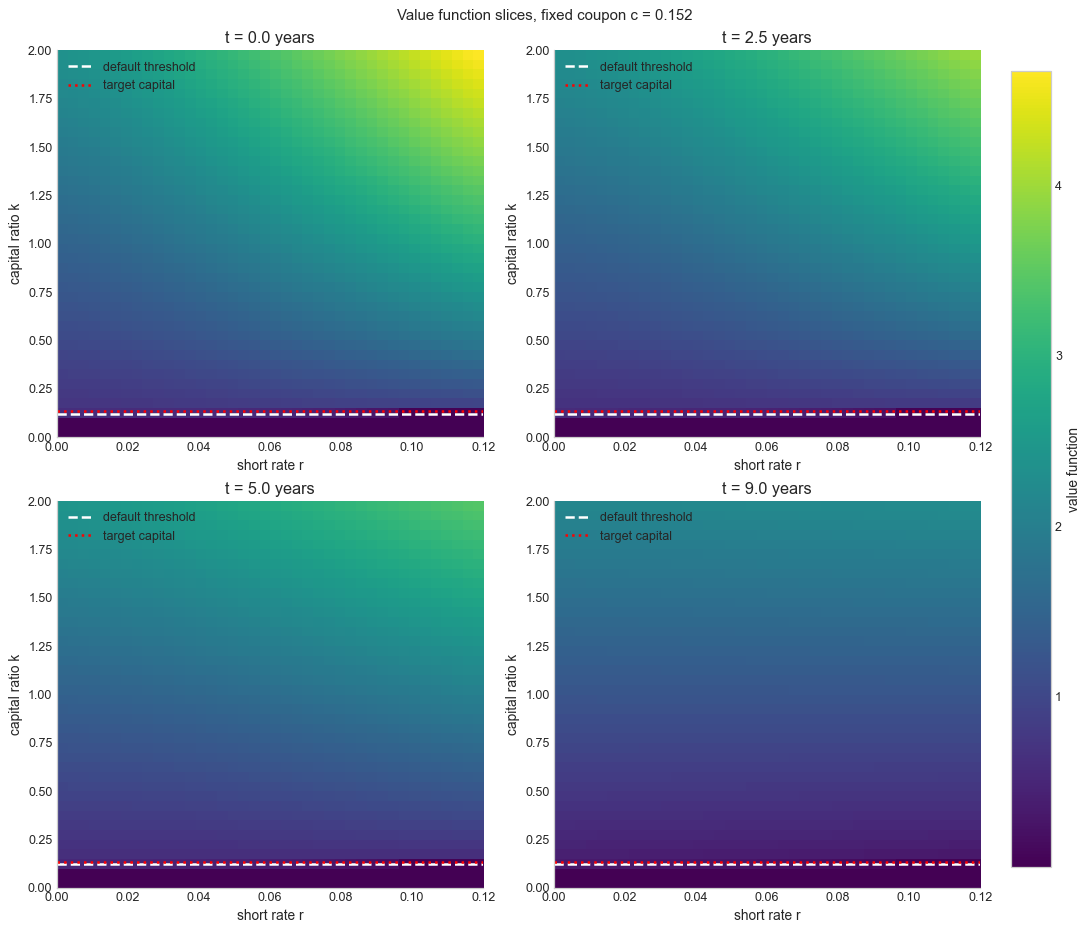

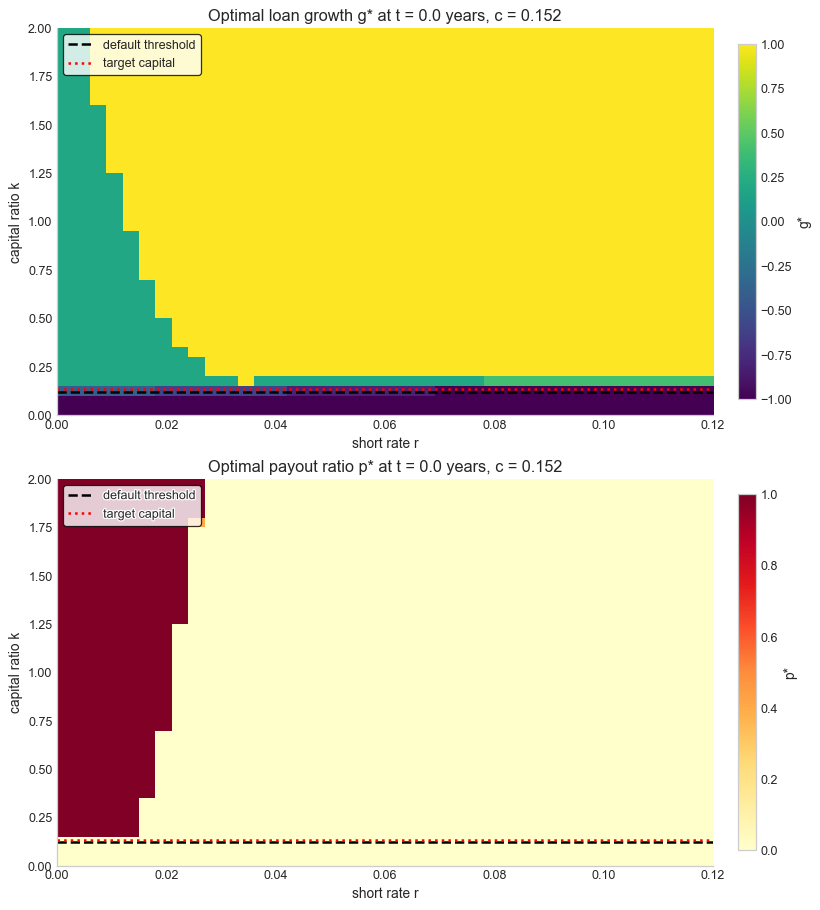

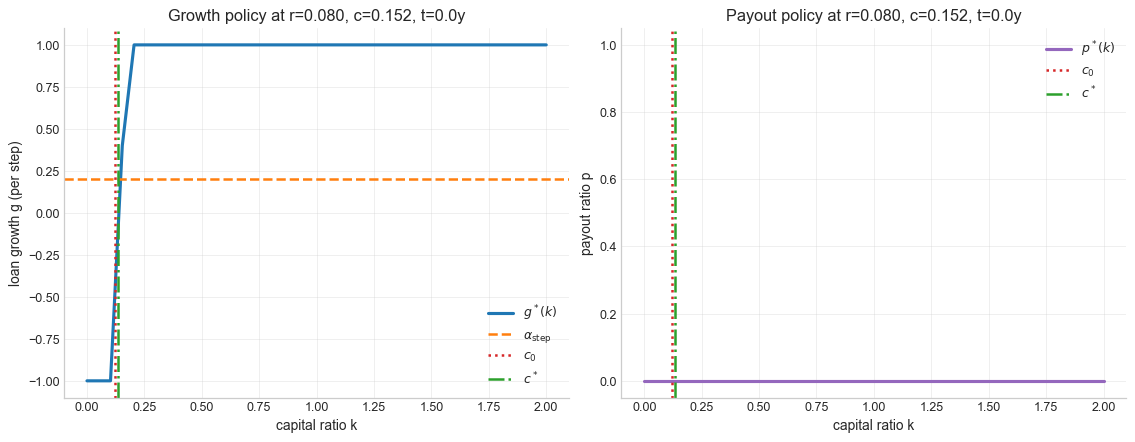

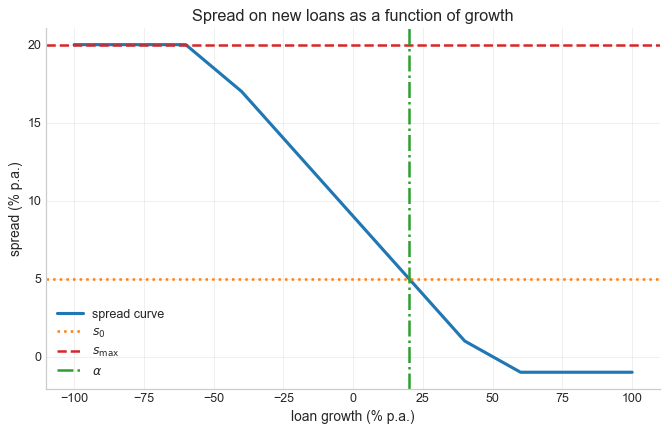

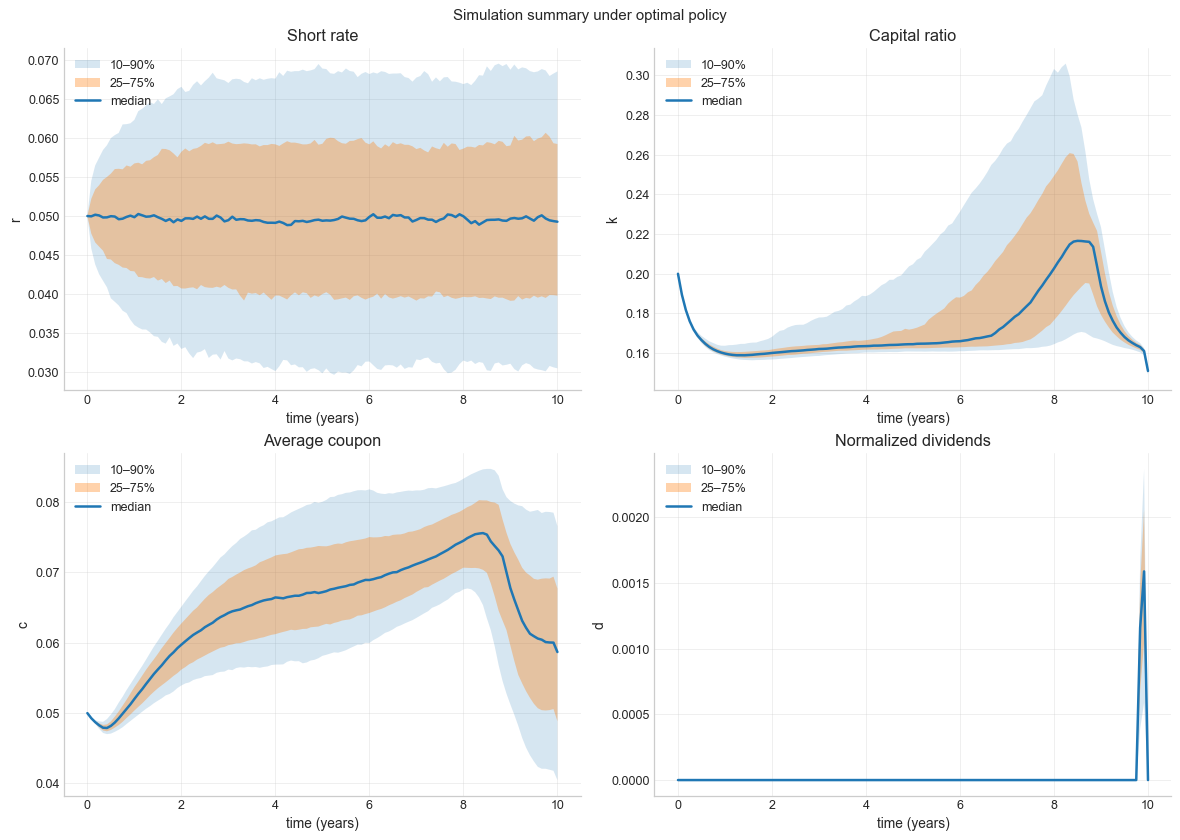

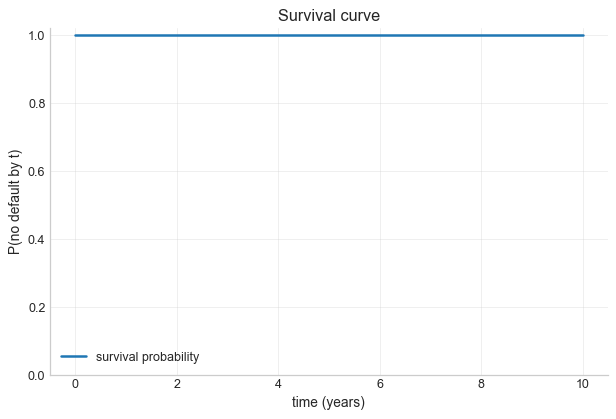

No defaults in the simulation sample.


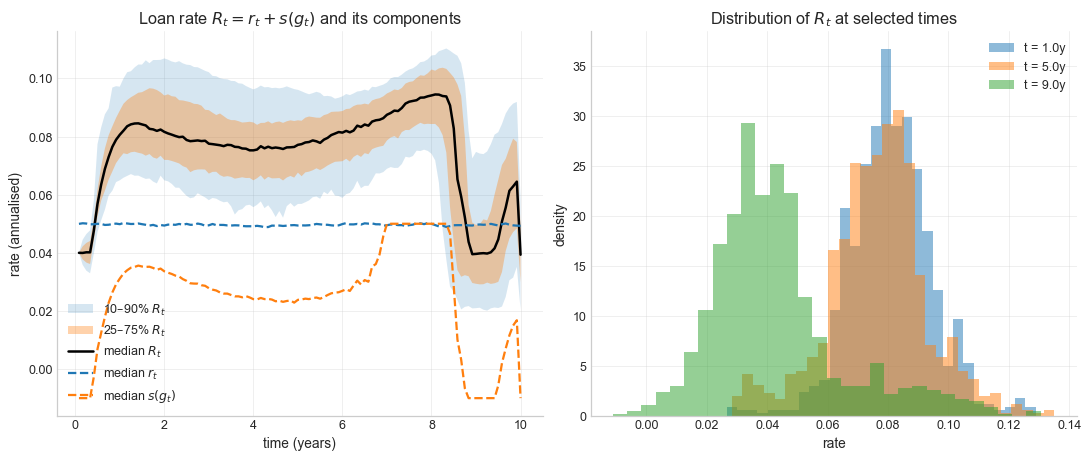

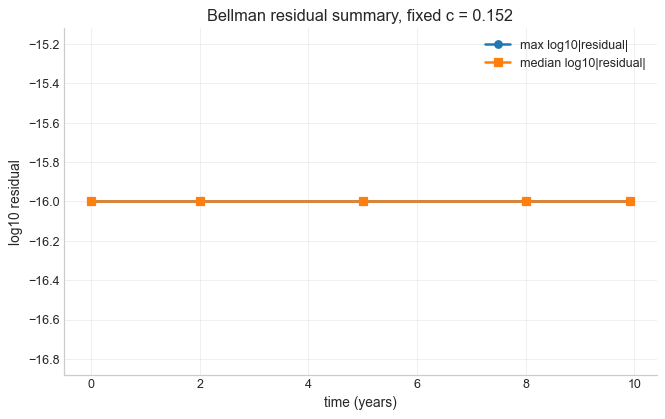

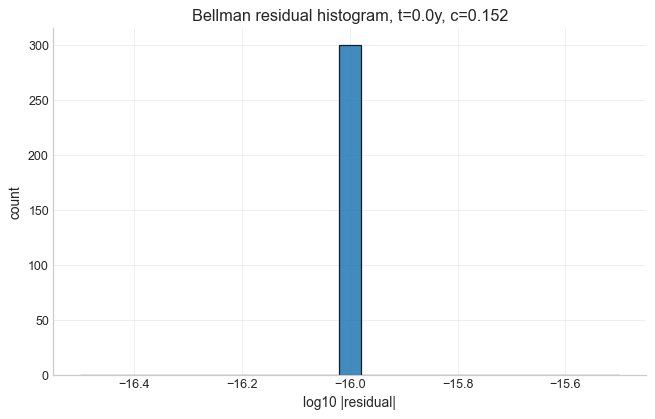

In [9]:
# set_plot_style()

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 90,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

plot_value_slices(solver, c_fixed=0.15, times_years=(0.0, 2.5, 5.0, 9.0))
plot_policy_maps(solver, t=0, c_fixed=0.15)
plot_policy_slices(solver, r_fixed=0.08, c_fixed=0.15, t=0)
plot_spread_curve(solver)

plot_simulation_quantiles(sim)
plot_survival_curve(sim)
plot_default_histogram(sim)
plot_loan_rate_distribution(solver, sim, times_years=(1.0, 5.0, 9.0))

plot_bellman_residual_summary(solver, c_fixed=0.15)
plot_bellman_residual_histogram(solver, c_fixed=0.15, t=0)

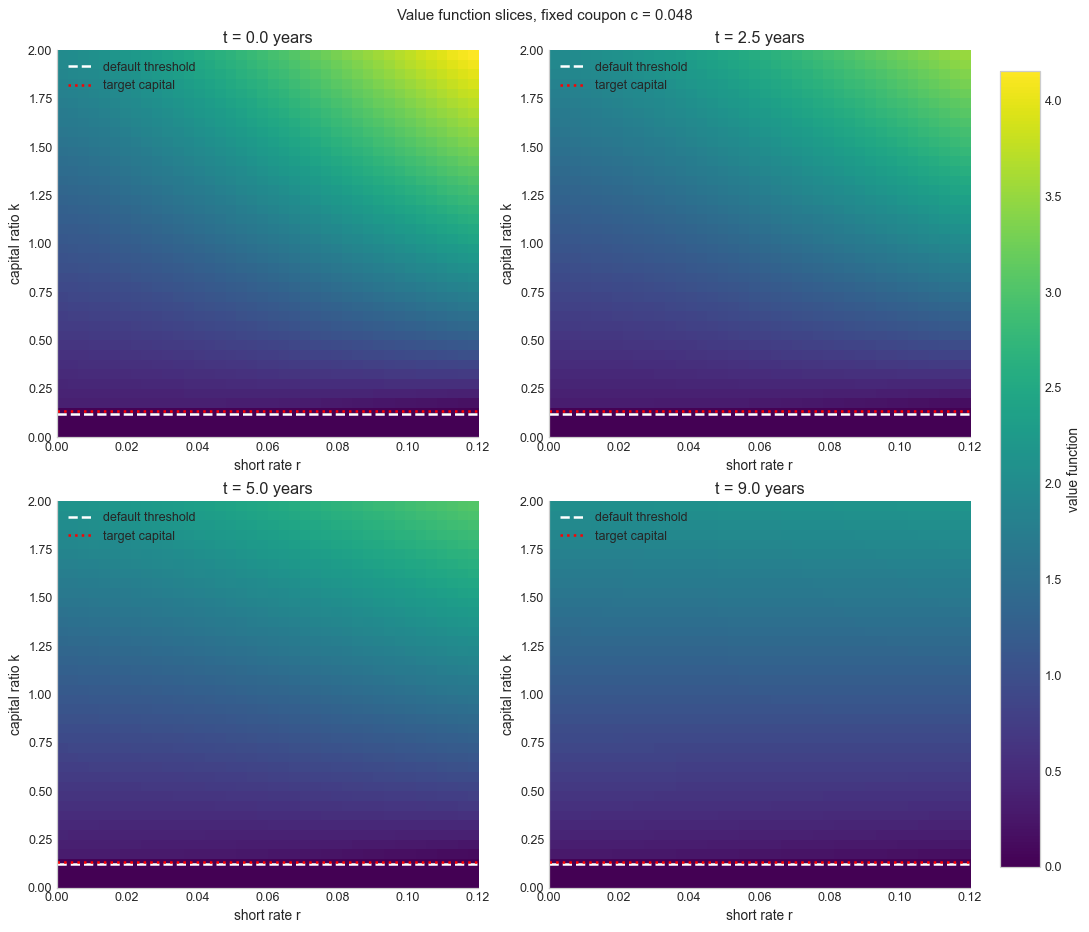

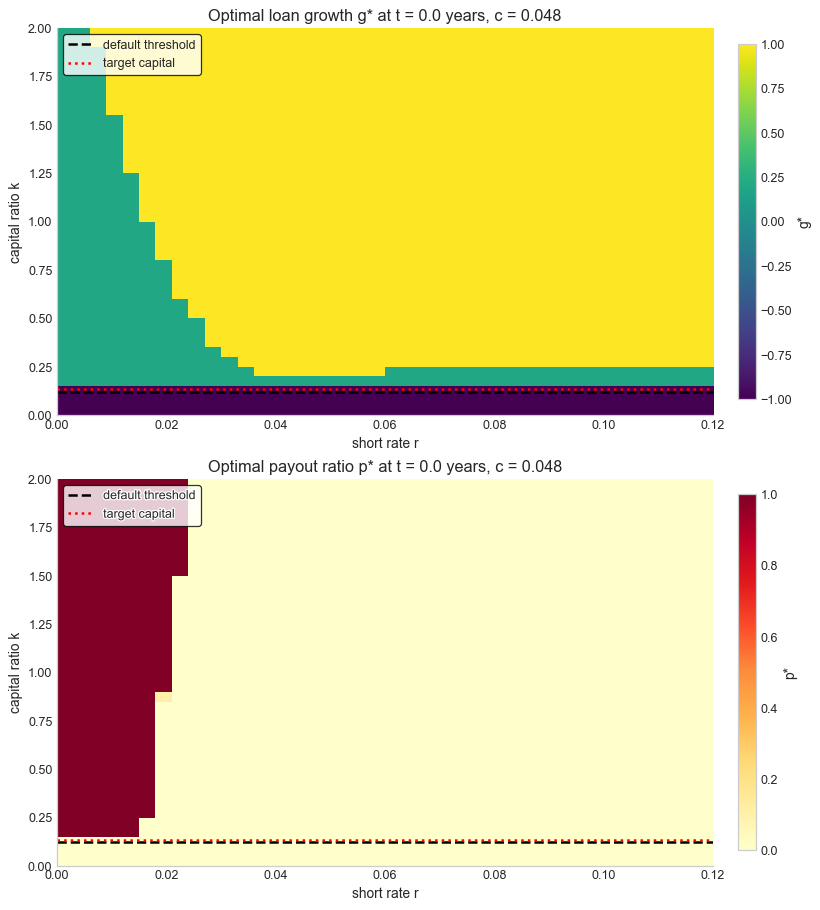

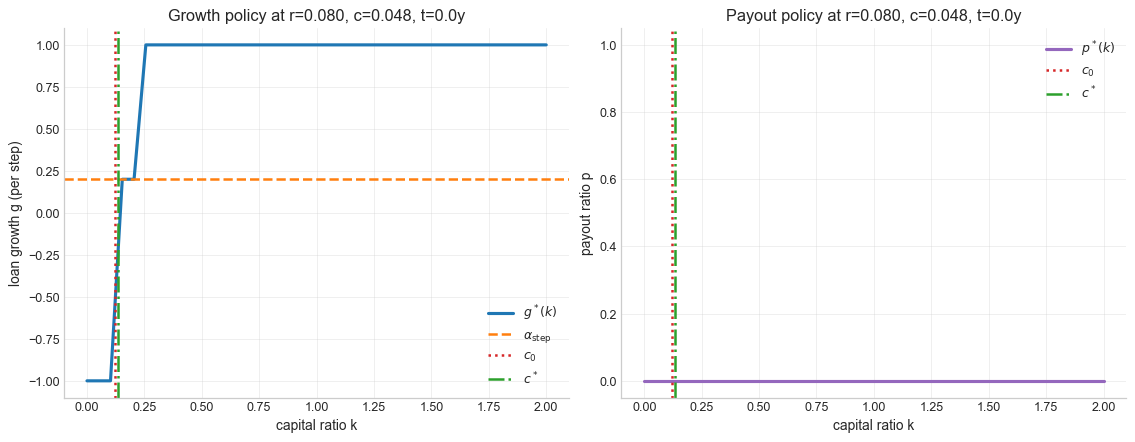

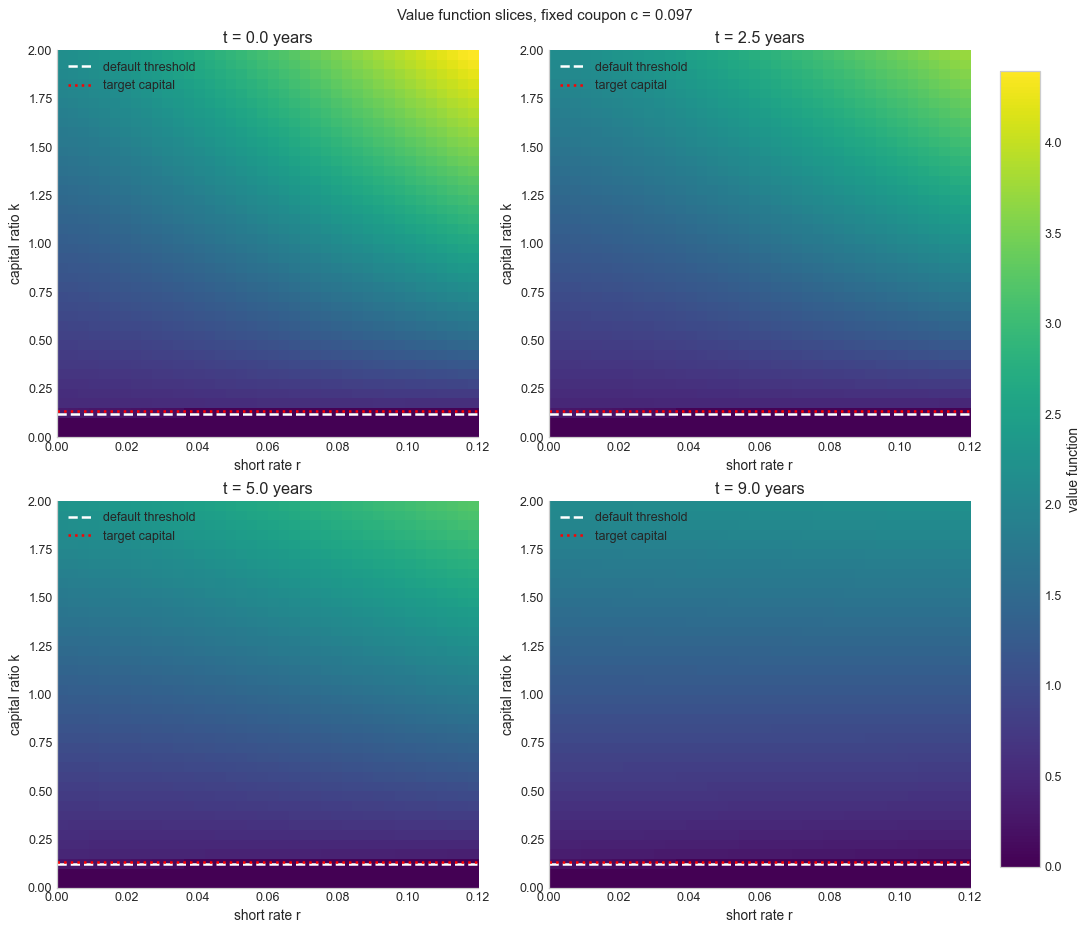

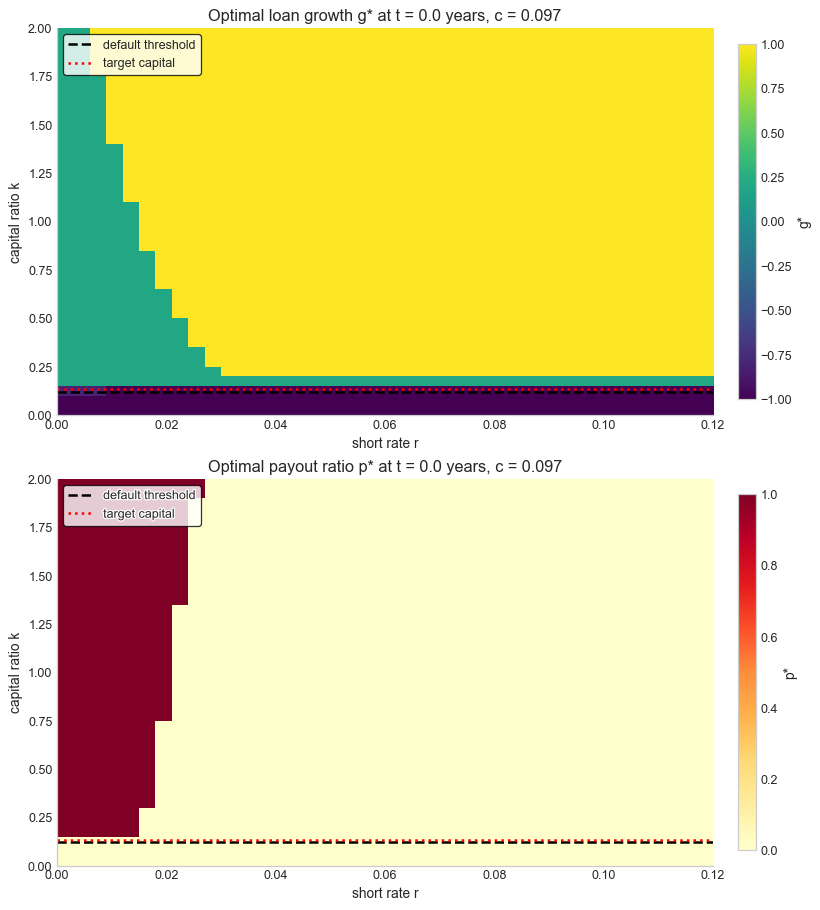

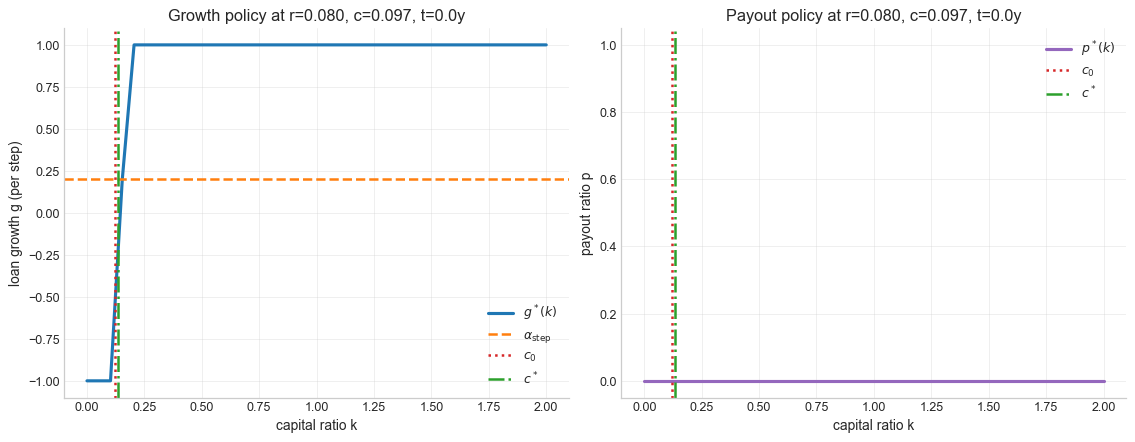

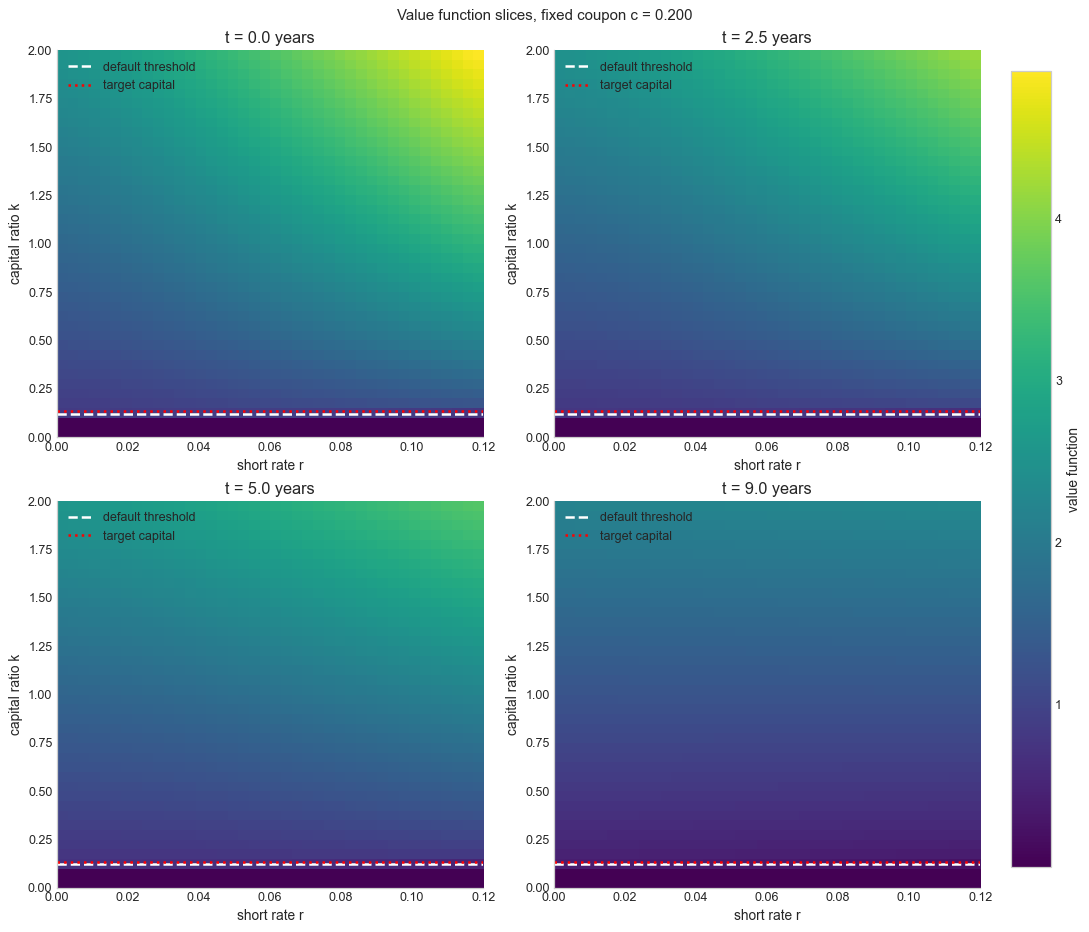

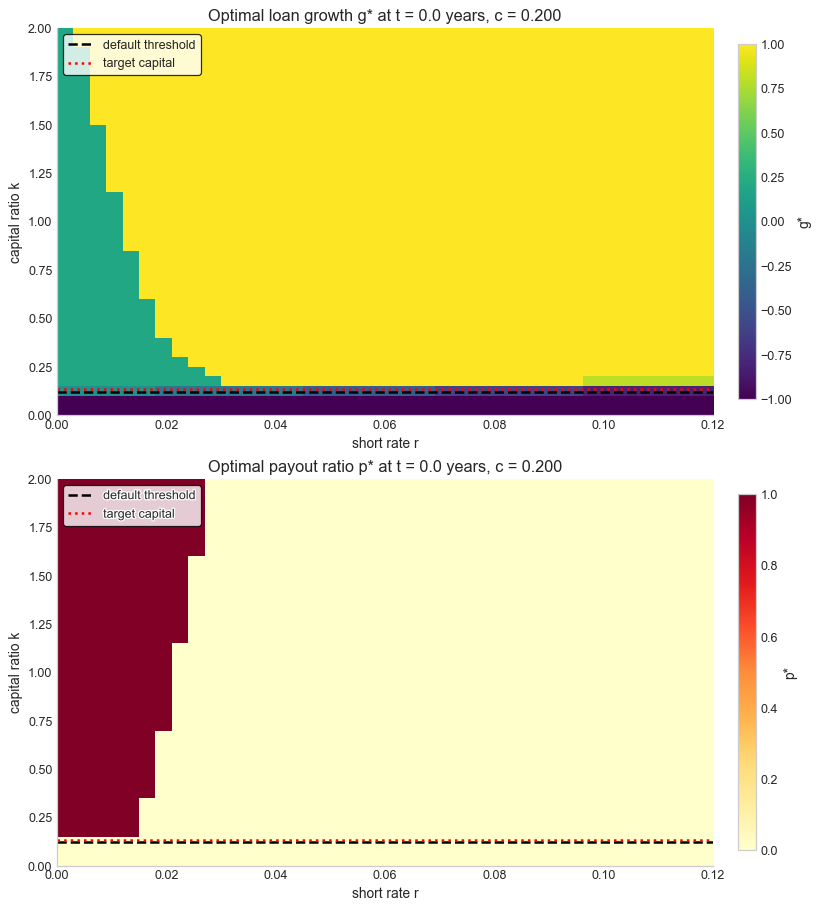

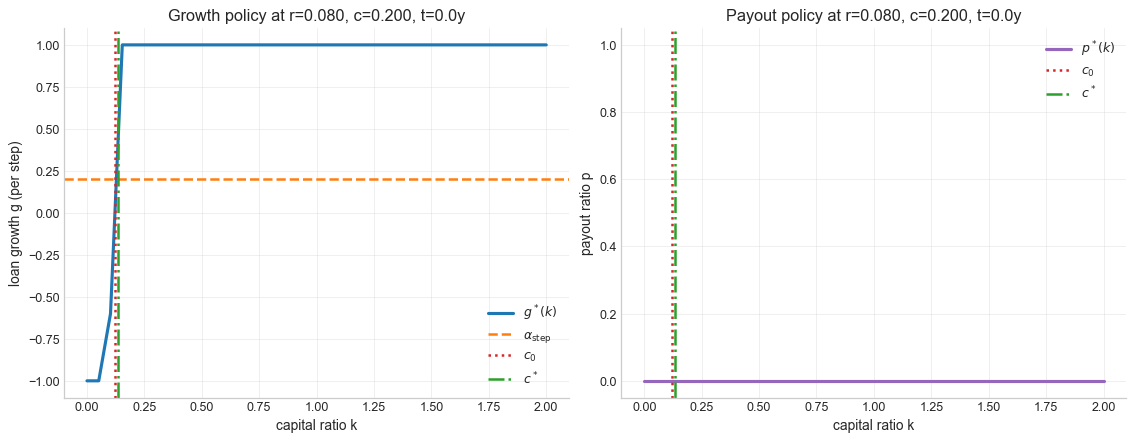

In [10]:
c_list = [0.05, 0.10, 0.20]

for c in c_list:
    plot_value_slices(solver, c_fixed=c, times_years=(0.0, 2.5, 5.0, 9.0))
    plot_policy_maps(solver, t=0, c_fixed=c)
    plot_policy_slices(solver, r_fixed=0.08, c_fixed=c, t=0)
    print('='*50)

==================== delta = 0.2 ====================


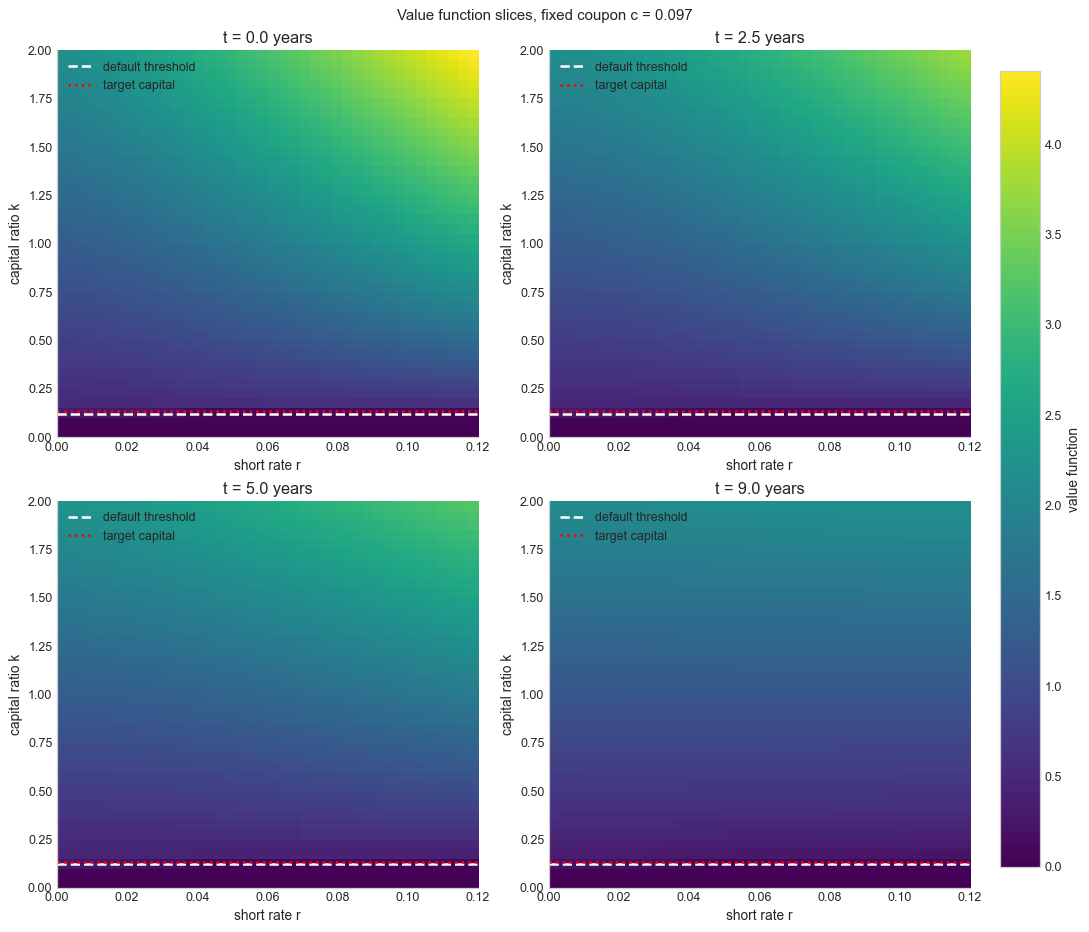

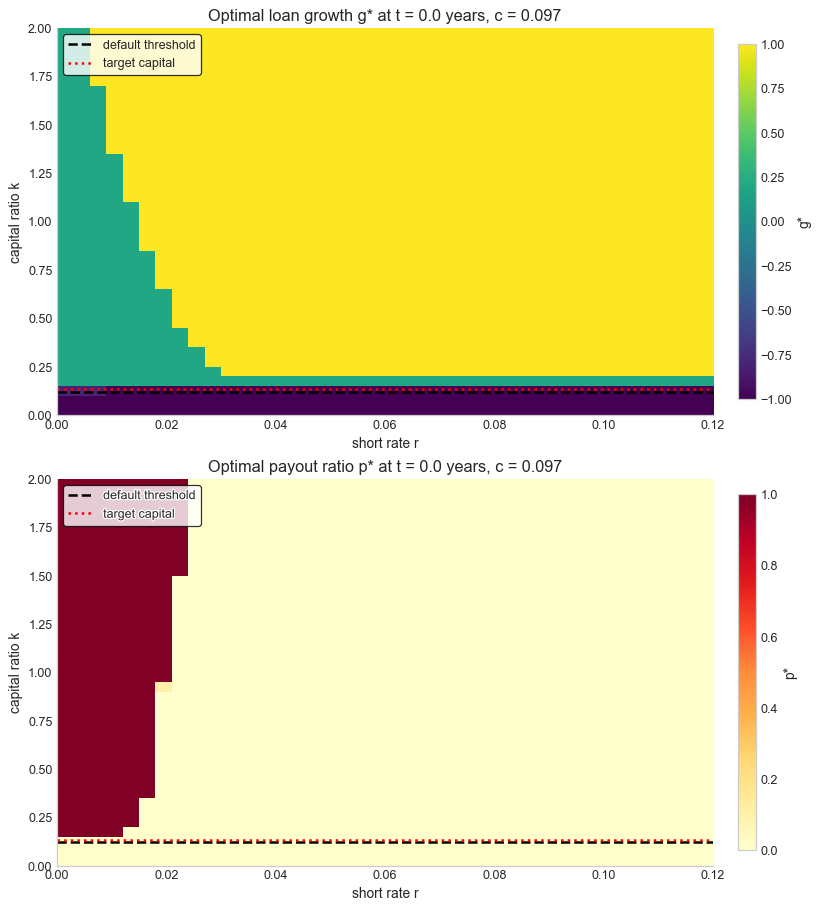

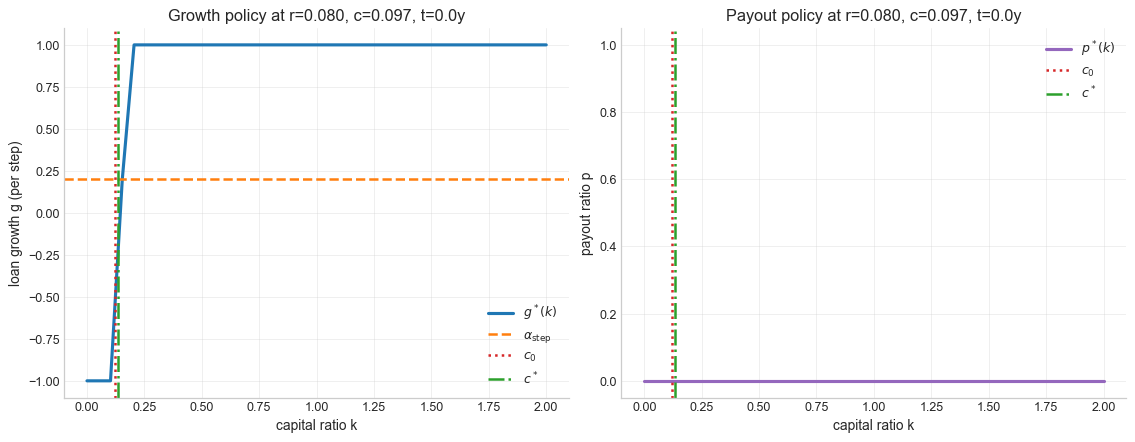

==================== delta = 0.5 ====================


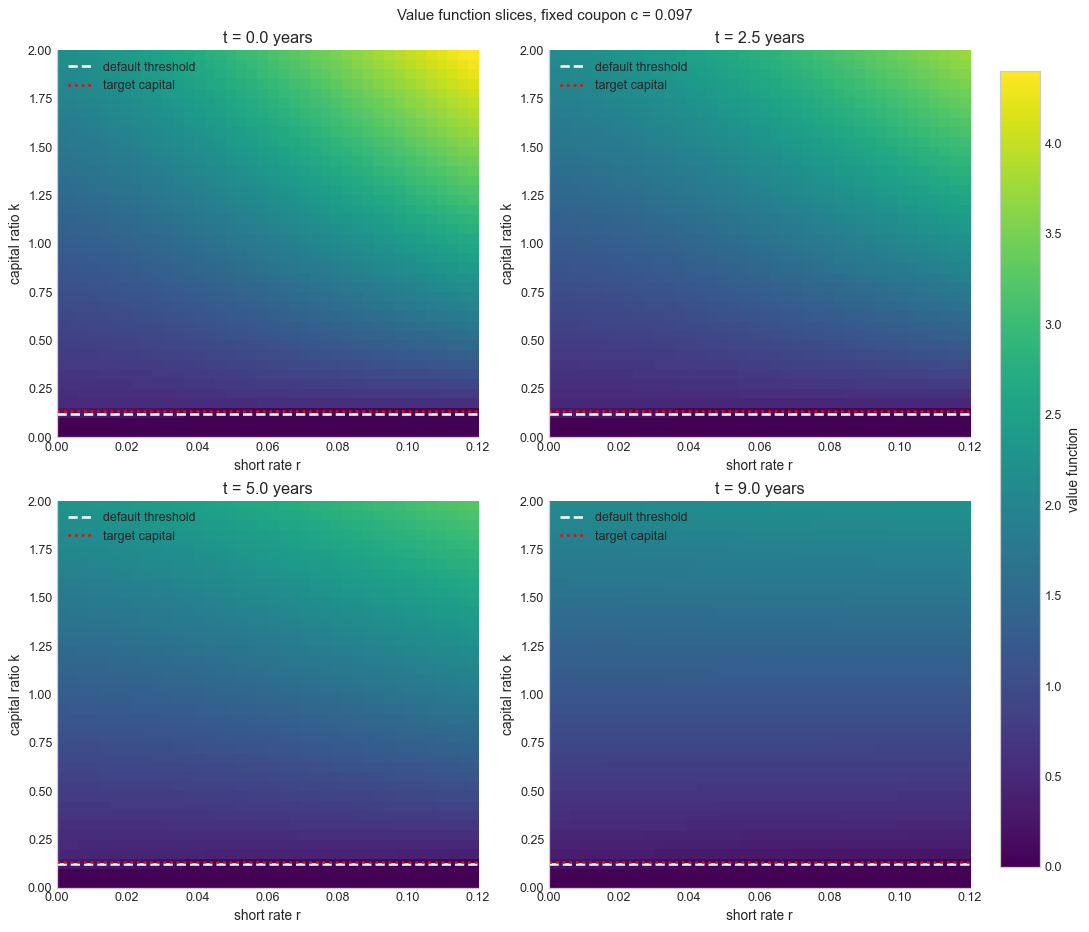

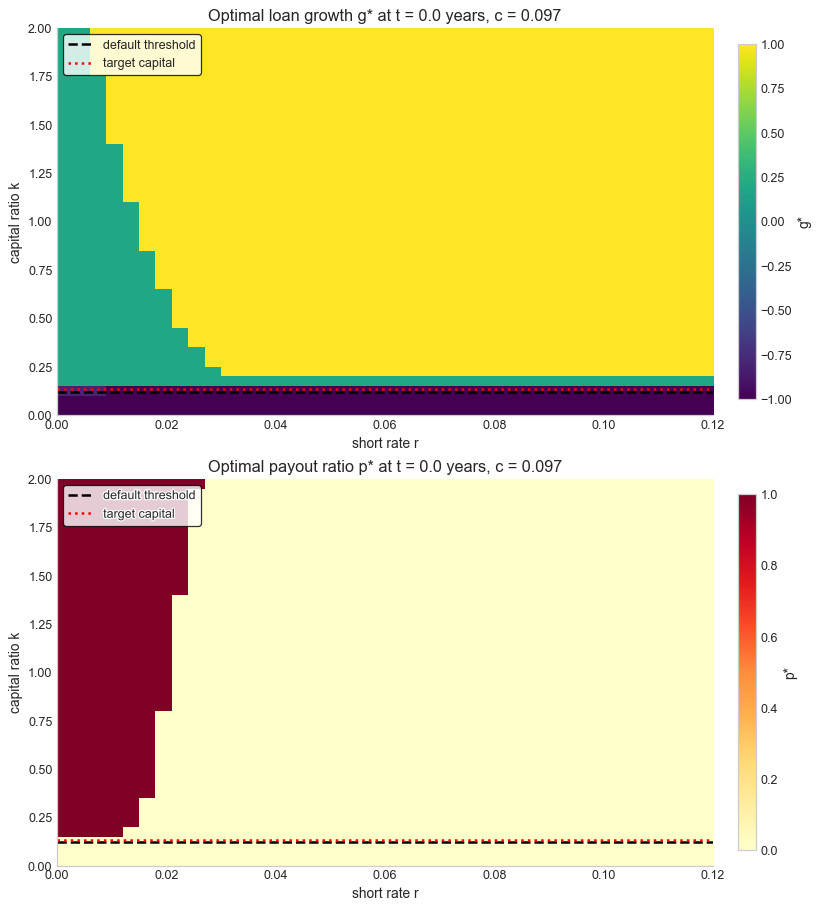

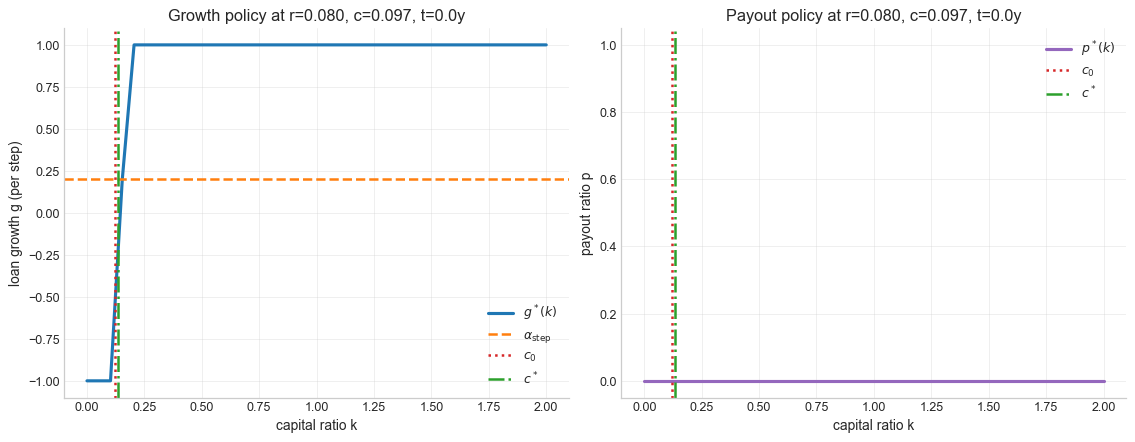

==================== delta = 0.8 ====================


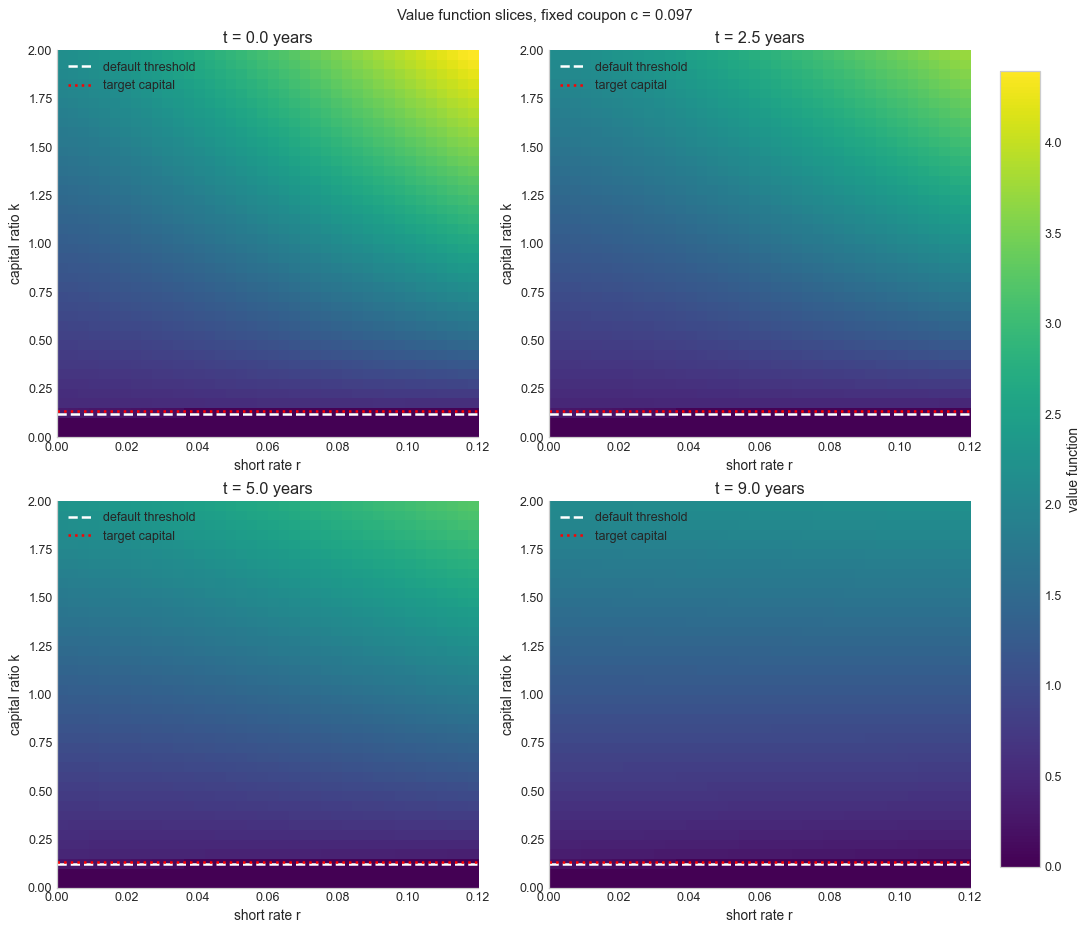

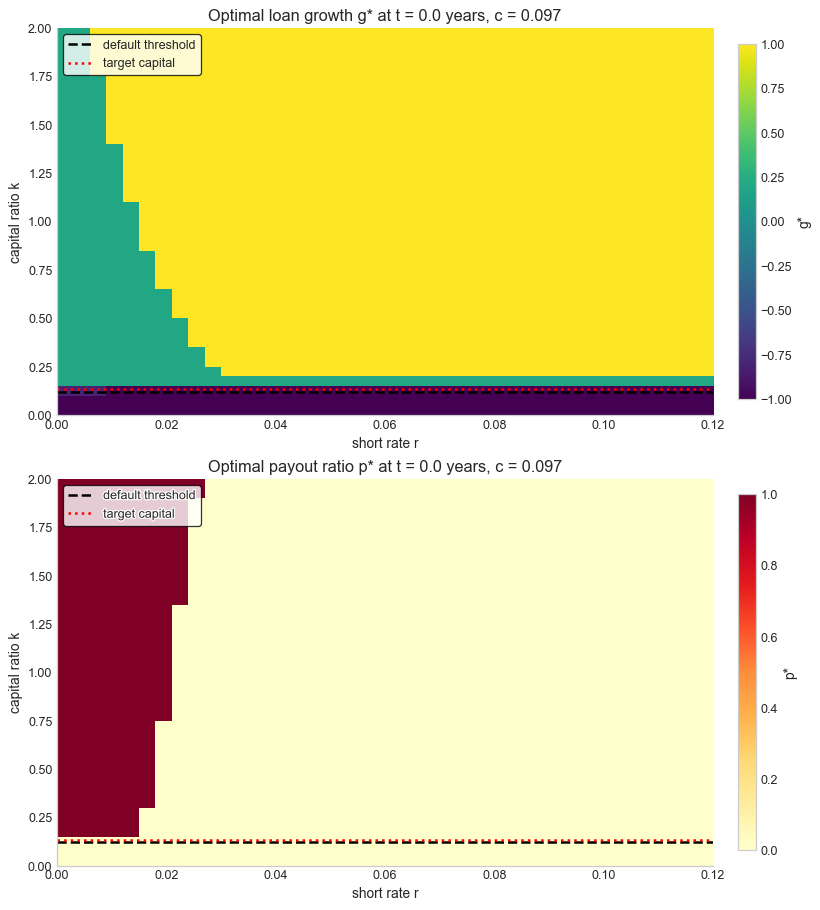

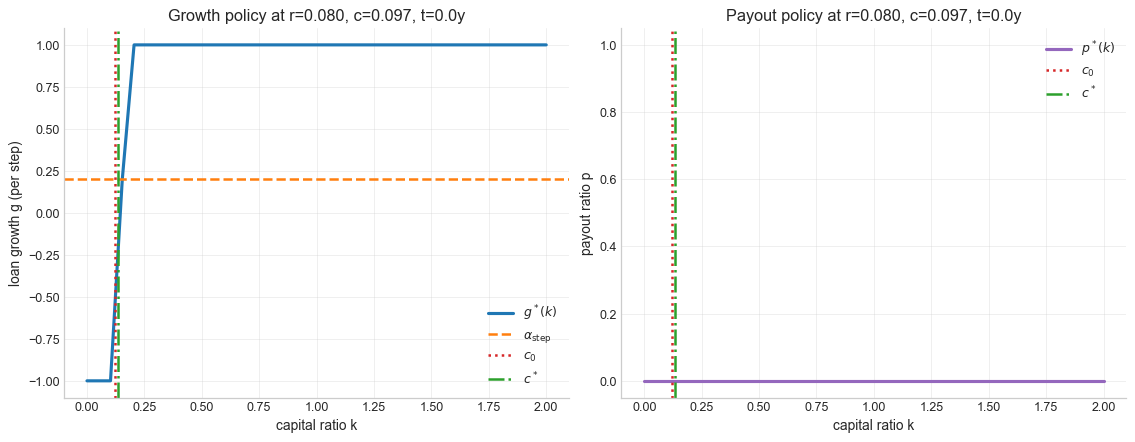

==================== delta = 0.95 ====================


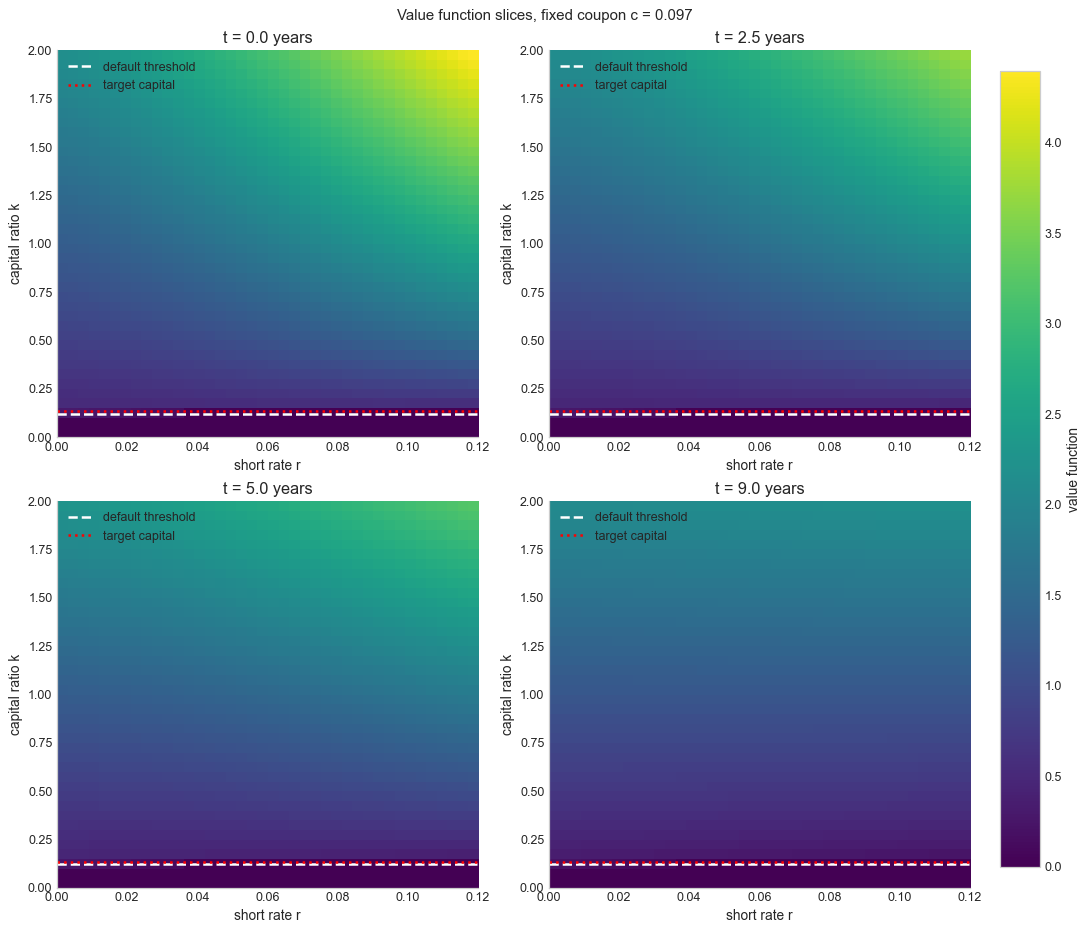

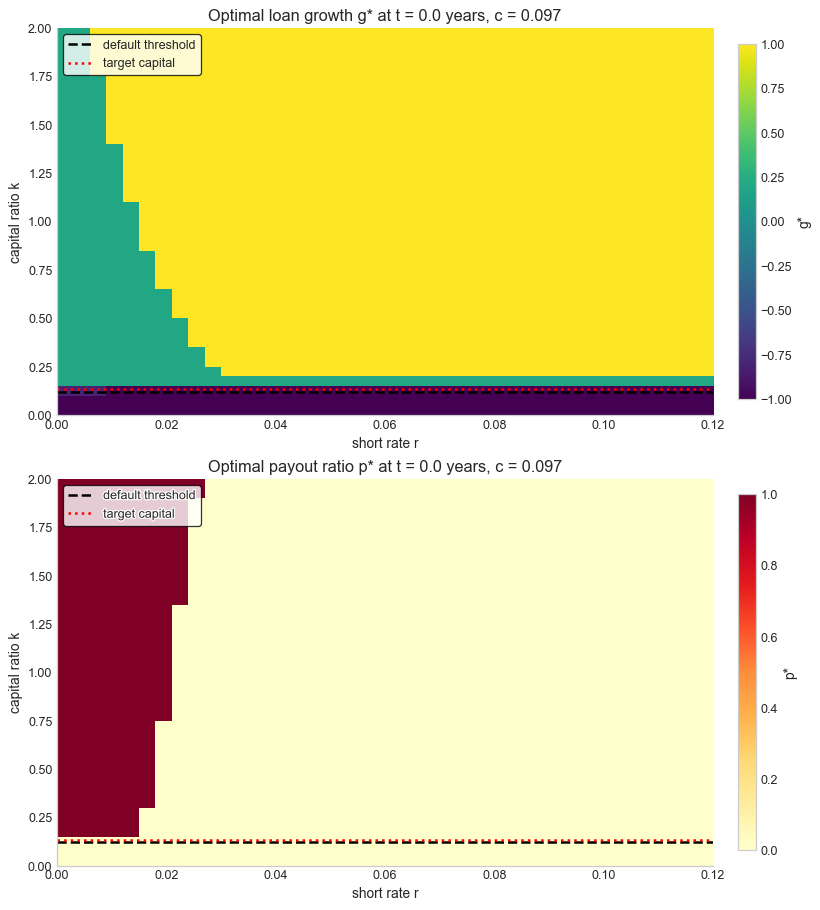

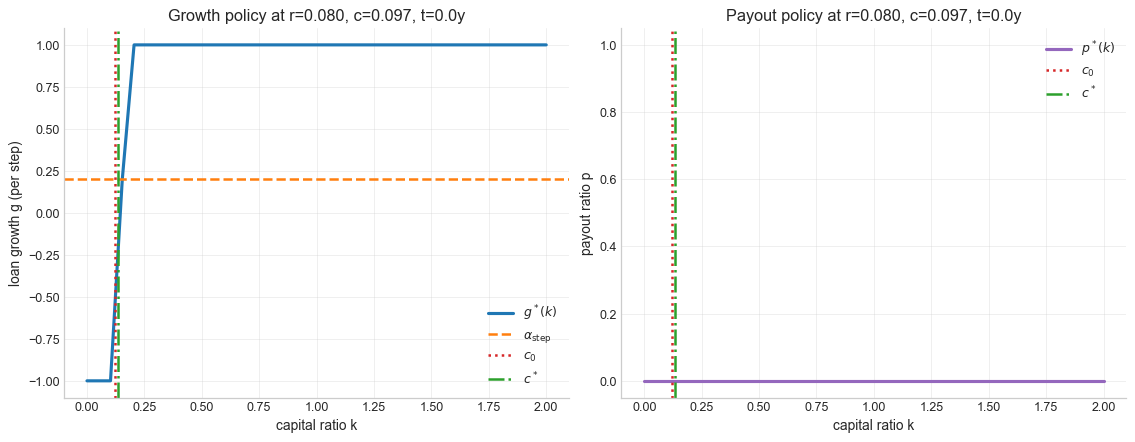

In [11]:
# Посмотрим как delta влияет на оптимальную политику при прочих равных
# theta_fixed = 0.1
for delta in [0.2, 0.5, 0.8, 0.95]:
    solver = LoanTraderSolver.load(f'solver_delta_{delta:.3f}.pkl')
    print('='*20, f'delta = {delta}', '='*20)
    plot_value_slices(solver, c_fixed=0.1, times_years=(0.0, 2.5, 5.0, 9.0))
    plot_policy_maps(solver, t=0, c_fixed=0.1)
    plot_policy_slices(solver, r_fixed=0.08, c_fixed=0.1, t=0)
